In [1]:
import tarfile
import pandas as pd
import numpy as np
import re
from datetime import datetime

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from keras.wrappers.scikit_learn import KerasClassifier

from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dropout, Activation, Flatten
from keras.layers import Embedding, LSTM, Dense, Bidirectional

from matplotlib import pyplot as plt

### Read data

In [2]:
filename = "training_data.tar.gz"

data = tarfile.open(filename, "r:gz")
data.extractall()
data.close()

In [3]:
b = open('ghl_gold.fa','r')
bind = b.readlines()
b.close()

u = open('ghl_gold_random.fa','r')
unbind = u.readlines()
u.close()

### Data preprocessing

In [4]:
bind = [v for v in bind if '>' not in v]
bind = [s.replace('\n', '') for s in bind]
bind = [x.upper() for x in bind]

unbind = [v for v in unbind if '>' not in v]
unbind = [s.replace('\n', '') for s in unbind]
unbind = [x.upper() for x in unbind]

In [5]:
print(len(bind), len(unbind))

1400090 1400090


In [6]:
bind_label = [1 for i in range(len(bind))]
unbind_label = [0 for i in range(len(unbind))]

In [7]:
bind_dict = {"seq":bind, "label":bind_label}
unbind_dict = {"seq":unbind, "label":unbind_label}

In [8]:
bind_df = pd.DataFrame(bind_dict)
unbind_df = pd.DataFrame(unbind_dict)

In [9]:
df = pd.concat([bind_df, unbind_df])

##### split the dataset

In [10]:
from sklearn.utils import shuffle

new_df = shuffle(df)
new_df = new_df.reset_index()

In [11]:
x = new_df.seq
y = new_df.label

In [12]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=40)

##### One-hot Encoding

In [13]:
LE = LabelEncoder()
LE.fit(['A', 'C', 'G', 'T', 'N'])

LabelEncoder()

In [14]:
start = datetime.now()

for index, row in x_train.items():
  x_train[index] = LE.transform(list(row))

for index, row in x_test.items():
  x_test[index] = LE.transform(list(row))

x_train = to_categorical(x_train.values.tolist())
x_t = to_categorical(x_test.values.tolist())

y_train = to_categorical(y_train.values.tolist())
y_t = to_categorical(y_test.values.tolist())

end = datetime.now()
print("encoding running time : "+str(end-start))

encoding running time : 0:02:43.492975


### RNN model

In [49]:
model = Sequential()
model.add(LSTM(128, input_shape=(20, 5), return_sequences=True))
model.add(LSTM(128))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(2, activation='softmax'))
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [50]:
model.summary()

Model: "sequential_11"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
lstm_29 (LSTM)               (None, 20, 128)           68608     
_________________________________________________________________
lstm_30 (LSTM)               (None, 128)               131584    
_________________________________________________________________
dense_20 (Dense)             (None, 64)                8256      
_________________________________________________________________
dropout_9 (Dropout)          (None, 64)                0         
_________________________________________________________________
dense_21 (Dense)             (None, 2)                 130       
Total params: 208,578
Trainable params: 208,578
Non-trainable params: 0
_________________________________________________________________


In [47]:
bi_model = Sequential()
bi_model.add(Bidirectional(LSTM(64, return_sequences=True), input_shape=(20, 5)))
bi_model.add(Bidirectional(LSTM(64)))
bi_model.add(Dense(64, activation='relu'))
bi_model.add(Dropout(0.2))
bi_model.add(Dense(2, activation='softmax'))
bi_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [48]:
bi_model.summary()

Model: "sequential_10"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
bidirectional_13 (Bidirectio (None, 20, 128)           35840     
_________________________________________________________________
bidirectional_14 (Bidirectio (None, 128)               98816     
_________________________________________________________________
dense_18 (Dense)             (None, 64)                8256      
_________________________________________________________________
dropout_8 (Dropout)          (None, 64)                0         
_________________________________________________________________
dense_19 (Dense)             (None, 2)                 130       
Total params: 143,042
Trainable params: 143,042
Non-trainable params: 0
_________________________________________________________________


In [51]:
history = model.fit(x_train, y_train, epochs = 10, validation_split = 0.2)

Epoch 1/10
56004/56004 [==============================] - 317s 6ms/step - loss: 0.3198 - accuracy: 0.8625 - val_loss: 0.2876 - val_accuracy: 0.8772
Epoch 2/10
56004/56004 [==============================] - 316s 6ms/step - loss: 0.2790 - accuracy: 0.8818 - val_loss: 0.2743 - val_accuracy: 0.8838
Epoch 3/10
56004/56004 [==============================] - 315s 6ms/step - loss: 0.2736 - accuracy: 0.8842 - val_loss: 0.2725 - val_accuracy: 0.8841
Epoch 4/10
56004/56004 [==============================] - 316s 6ms/step - loss: 0.2695 - accuracy: 0.8860 - val_loss: 0.2715 - val_accuracy: 0.8851
Epoch 5/10
56004/56004 [==============================] - 314s 6ms/step - loss: 0.2667 - accuracy: 0.8876 - val_loss: 0.2713 - val_accuracy: 0.8854
Epoch 6/10
56004/56004 [==============================] - 314s 6ms/step - loss: 0.2653 - accuracy: 0.8878 - val_loss: 0.2712 - val_accuracy: 0.8853
Epoch 7/10
56004/56004 [==============================] - 314s 6ms/step - loss: 0.2646 - accuracy: 0.8882 - val_

In [52]:
bi_history = bi_model.fit(x_train, y_train, epochs = 10, validation_split = 0.2)

Epoch 1/10
56004/56004 [==============================] - 528s 9ms/step - loss: 0.3215 - accuracy: 0.8616 - val_loss: 0.2804 - val_accuracy: 0.8819
Epoch 2/10
56004/56004 [==============================] - 521s 9ms/step - loss: 0.2804 - accuracy: 0.8815 - val_loss: 0.2750 - val_accuracy: 0.8835
Epoch 3/10
56004/56004 [==============================] - 522s 9ms/step - loss: 0.2744 - accuracy: 0.8839 - val_loss: 0.2731 - val_accuracy: 0.8838
Epoch 4/10
56004/56004 [==============================] - 519s 9ms/step - loss: 0.2703 - accuracy: 0.8857 - val_loss: 0.2743 - val_accuracy: 0.8845
Epoch 5/10
56004/56004 [==============================] - 518s 9ms/step - loss: 0.2687 - accuracy: 0.8863 - val_loss: 0.2723 - val_accuracy: 0.8851
Epoch 6/10
56004/56004 [==============================] - 516s 9ms/step - loss: 0.2659 - accuracy: 0.8876 - val_loss: 0.2724 - val_accuracy: 0.8850
Epoch 7/10
56004/56004 [==============================] - 513s 9ms/step - loss: 0.2639 - accuracy: 0.8886 - val_

##### Evaluation

Accuracy

In [58]:
score = model.evaluate(x_t, y_t)
print("score = " + str(round(score[1],2)))

17502/17502 [==============================] - 53s 3ms/step - loss: 0.2729 - accuracy: 0.8852
score = 0.89


In [59]:
bi_score = bi_model.evaluate(x_t, y_t)
print("score = " + str(round(bi_score[1],2)))

17502/17502 [==============================] - 73s 4ms/step - loss: 0.2750 - accuracy: 0.8848
score = 0.88


loss-epoch curve

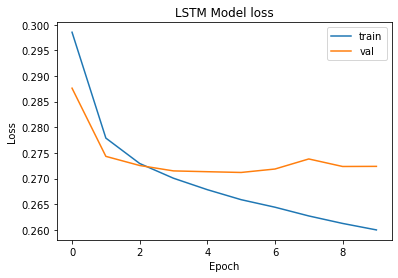

In [60]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('LSTM Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'val'], loc='upper right')
plt.show()

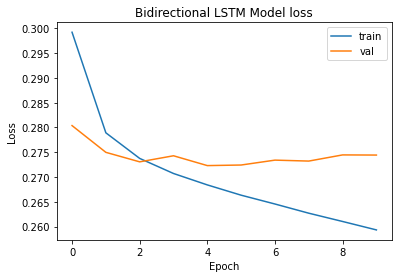

In [61]:
plt.plot(bi_history.history['loss'])
plt.plot(bi_history.history['val_loss'])
plt.title('Bidirectional LSTM Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'val'], loc='upper right')
plt.show()

precision-recall curve

In [62]:
probs = model.predict(x_t)[:,1]
bi_probs = bi_model.predict(x_t)[:,1]

In [63]:
precision, recall, thresholds = precision_recall_curve(y_test.values, probs)
bi_precision, bi_recall, bi_thresholds = precision_recall_curve(y_test.values, bi_probs)

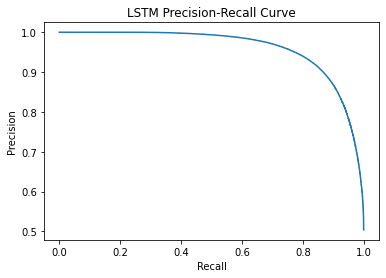

In [64]:
plt.plot(recall, precision)

plt.title('LSTM Precision-Recall Curve')

plt.xlabel('Recall')
plt.ylabel('Precision')

plt.show()

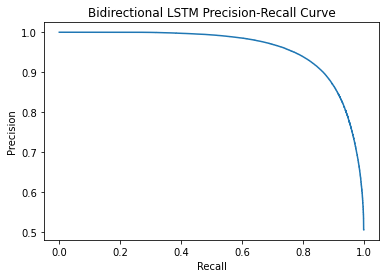

In [65]:
plt.plot(bi_recall, bi_precision)

plt.title('Bidirectional LSTM Precision-Recall Curve')

plt.xlabel('Recall')
plt.ylabel('Precision')

plt.show()

ROC curve & AUC

In [66]:
auc = roc_auc_score(y_test.values, probs)
fpr, tpr, _ = roc_curve(y_test.values, probs)

bi_auc = roc_auc_score(y_test.values, bi_probs)
bi_fpr, bi_tpr, bi_ = roc_curve(y_test.values, bi_probs)

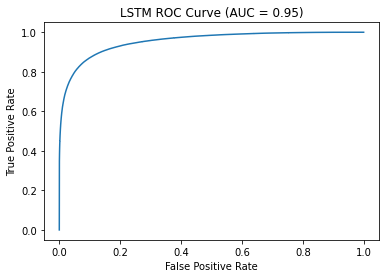

In [67]:
plt.plot(fpr, tpr)
plt.title('LSTM ROC Curve (AUC = ' + str(round(auc,2)) + ')')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

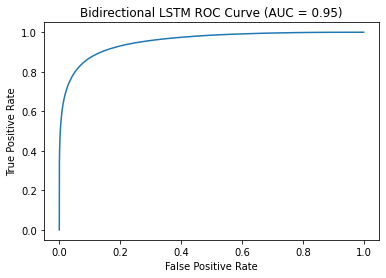

In [68]:
plt.plot(bi_fpr, bi_tpr)
plt.title('Bidirectional LSTM ROC Curve (AUC = ' + str(round(bi_auc,2)) + ')')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()